In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

df = pd.read_csv("data\pa_transactor_annotated_clean.csv")

(array([1952.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1952.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

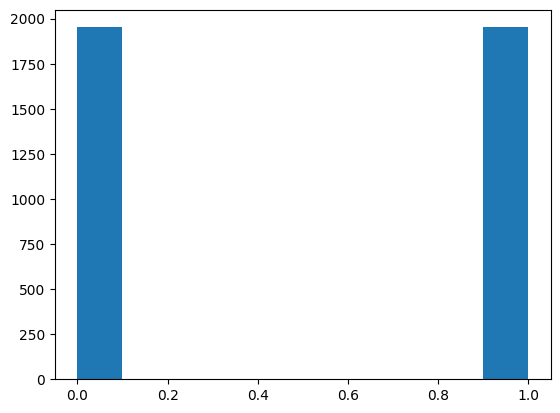

In [133]:
# # clean string columns
# for col in ['transactor_type', 'reported_state', 'party', 'full_name']:
#     df[col] = df[col].astype(str).str.strip().str.title()

# # replace filler or unknown values with NA
# filler_values = ['Na', 'N/A', 'None', 'Unknown', 'Nan']
# df.replace(filler_values, pd.NA, inplace=True)

# # drop rows with missing key fields
# df.dropna(subset=['full_name', 'transactor_type', 'reported_state', 'party'], inplace=True)

# # drop duplicate donors based on id or name
# df = df.drop_duplicates(subset=['full_name'])

# encode transactor_type as numeric labels
df['label'] = df['transactor_type'].factorize()[0]

# features and target for under-sampling
X = df[['id', 'full_name', 'reported_state', 'party']]
y = df['label']

# apply random under-sampling to balance the classes
rus = RandomUnderSampler(random_state = 42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# merge resampled data with full original data
# df_resampled = pd.concat([X_resampled, y_resampled.rename("label")], axis = 1)

plt.hist(y_resampled)

In [120]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X_resampled['full_name'])

In [121]:
# def convert_bool(input_label):
#     '''Converts to numerical encoding'''
#     if input_label == 'Committee':
#         return 1
#     else:
#         return 0
# y = np.vectorize(convert_bool)(df['transactor_type'])
# y = df_resampled['label']

(array([502.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 474.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

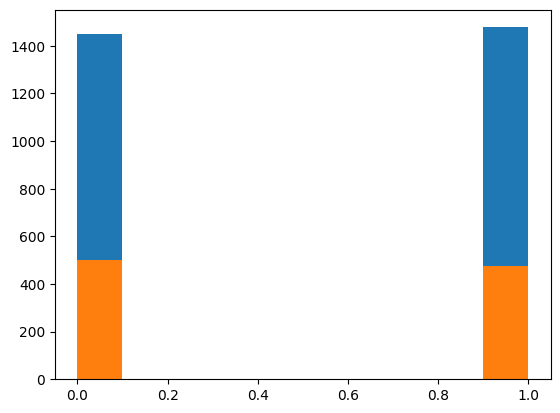

In [122]:
X_train, X_val, y_train, y_val = train_test_split(X, y_resampled, test_size = 0.25, random_state = 42)
plt.hist(y_train)
plt.hist(y_val)

In [123]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
predicted_y = rfc.predict(X_val)

In [124]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)

Accuracy: 97.1311475409836
Recall: 99.15611814345992
Precision: 95.1417004048583
f1_score: 97.10743801652893


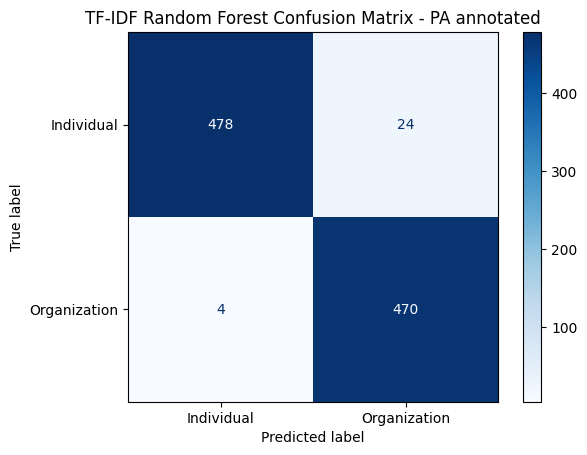

In [125]:
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("TF-IDF Random Forest Confusion Matrix - PA annotated")
#plt.savefig('TF-IDF Random Forest Confusion Matrix - PA annotated.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [126]:
y_val

3470    0
6499    1
115     1
1839    1
4434    0
       ..
6878    0
9100    1
9176    1
5042    1
7786    1
Name: label, Length: 976, dtype: int64

In [127]:
misclassified = np.where(y_val != predicted_y)[0]
misclassified


array([ 77,  99, 109, 110, 150, 177, 242, 250, 314, 341, 354, 367, 378,
       383, 386, 497, 577, 615, 616, 656, 691, 692, 765, 788, 797, 925,
       933, 955])

In [128]:
y_val_df = y_val.reset_index().copy()
y_val_df

,index,label
0,3470,0
1,6499,1
2,115,1
3,1839,1
4,4434,0
...,...,...
971,6878,0
972,9100,1
973,9176,1
974,5042,1


In [ ]:

inverse_names = vectorizer.inverse_transform(X_val)

inverse_names_clean = []
for i in misclassified:
	inverse_names_clean.append(" ".join(list(inverse_names[i])))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
	ctr+=1
	print(f"ctr: {ctr}")
	print(f"Index: {i}")
	print(f"Full Name: {inverse_names_clean[ctr]}")
	print(f"True Label: {y_val_df.iloc[i]['label']}, Predicted: {predicted_y[i]}")
	print("---")
# Committee = 0
# Individual = 1

Number of misclassified samples: 28
ctr: 0
Index: 77
Full Name: robey annmarie
True Label: 0, Predicted: 1
---
ctr: 1
Index: 99
Full Name: meshpac
True Label: 0, Predicted: 1
---
ctr: 2
Index: 109
Full Name: progress 2000
True Label: 0, Predicted: 1
---
ctr: 3
Index: 110
Full Name: firepac philadlphia
True Label: 0, Predicted: 1
---
ctr: 4
Index: 150
Full Name: jr alex minishak
True Label: 0, Predicted: 1
---
ctr: 5
Index: 177
Full Name: eric mock
True Label: 0, Predicted: 1
---
ctr: 6
Index: 242
Full Name: vote ventre
True Label: 0, Predicted: 1
---
ctr: 7
Index: 250
Full Name: national gas nfgpac fuel
True Label: 0, Predicted: 1
---
ctr: 8
Index: 314
Full Name: pac45
True Label: 0, Predicted: 1
---
ctr: 9
Index: 341
Full Name: judge julia munley
True Label: 1, Predicted: 0
---
ctr: 10
Index: 354
Full Name: for republican comm john pa 25 ritter monroeville
True Label: 1, Predicted: 0
---
ctr: 11
Index: 367
Full Name: afl cio erie
True Label: 0, Predicted: 1
---
ctr: 12
Index: 378
Full